# Traffic Flow Prediction using GRU
This notebook builds, trains, and evaluates a Gated Recurrent Unit (GRU) model to predict traffic flow on different SCATS road segments (movements) using the processed SCATS dataset.

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
from google.colab import drive

In [4]:
drive.mount('/content/drive')
# %cd /content/drive/MyDrive/cos30019-assignment-2b/notebooks

Mounted at /content/drive


In [5]:
import os
print("Current Directory:", os.getcwd())

# change to /content/drive/Othercomputers/My Laptop/cos30019-assignment-2b/notebooks
os.chdir('/content/drive/Othercomputers/My Mac/cos30019-assignment-2b/notebooks')

Current Directory: /content


## 2. Load and Inspect Traffic Data

In [6]:
data_path = "../data/processed/traffic_data.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nUnique movement IDs:")
print(df['movement_id'].unique())

Dataset shape: (47544, 7)

First 5 rows:


,movement_id,scats_number,location,DateTime,dayofweek,isweekend,hourly_traffic_volume
0,2000_1,2000,BURWOOD_HWY E OF WARRIGAL_RD,01/10/2006 00:00,6,1,225
1,2000_1,2000,BURWOOD_HWY E OF WARRIGAL_RD,01/10/2006 01:00,6,1,208
2,2000_1,2000,BURWOOD_HWY E OF WARRIGAL_RD,01/10/2006 02:00,6,1,154
3,2000_1,2000,BURWOOD_HWY E OF WARRIGAL_RD,01/10/2006 03:00,6,1,120
4,2000_1,2000,BURWOOD_HWY E OF WARRIGAL_RD,01/10/2006 04:00,6,1,94



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47544 entries, 0 to 47543
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   movement_id            47544 non-null  object
 1   scats_number           47544 non-null  int64 
 2   location               47544 non-null  object
 3   DateTime               47544 non-null  object
 4   dayofweek              47544 non-null  int64 
 5   isweekend              47544 non-null  int64 
 6   hourly_traffic_volume  47544 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 2.5+ MB

Unique movement IDs:
['2000_1' '2000_2' '2000_3' '2000_4' '2820_1' '2820_2' '2825_1' '2827_1'
 '2827_2' '2827_3' '2827_4' '3002_1' '3002_2' '3002_3' '3002_4' '3120_1'
 '3120_2' '3120_3' '3120_4' '3127_1' '3127_2' '3127_3' '3180_1' '3180_2'
 '3180_3' '3662_1' '3662_2' '3662_3' '3662_4' '3682_1' '3682_2' '3682_3'
 '3682_4' '4032_1' '4032_2' '4032_3' '4032_4' '4043_1'

Let's visualize the traffic flow for a sample movement (e.g., `2000_1`) over the first week.

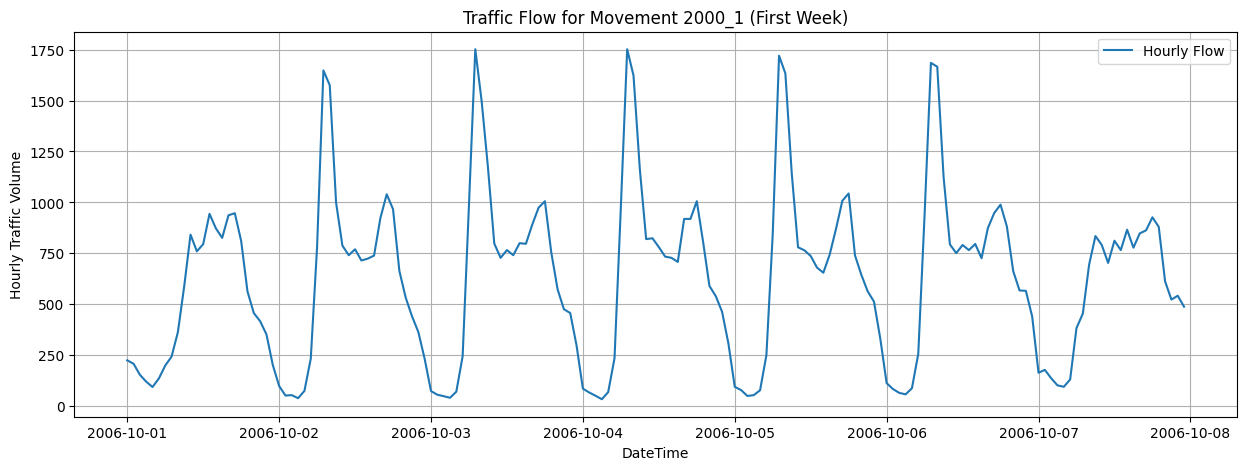

In [7]:
# Convert DateTime column
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M')

# Filter for one movement ID
sample_movement = '2000_1'
sample_df = df[df['movement_id'] == sample_movement].sort_values('DateTime')

plt.figure(figsize=(15, 5))
plt.plot(sample_df['DateTime'][:168], sample_df['hourly_traffic_volume'][:168], label='Hourly Flow')
plt.title(f"Traffic Flow for Movement {sample_movement} (First Week)")
plt.xlabel("DateTime")
plt.ylabel("Hourly Traffic Volume")
plt.legend()
plt.grid(True)
plt.show()

## 3. Data Preprocessing & Scaling

In [8]:
# 1. Handle missing values (check for nulls or zeros that might indicate missing values)
print("Missing values:", df['hourly_traffic_volume'].isnull().sum())

# Apply linear interpolation on volume
df['hourly_traffic_volume'] = df['hourly_traffic_volume'].interpolate(method='linear')

# 2. Extract temporal features
df['hour_of_day'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek

# 3. Scale the flow values using MinMaxScaler
scaler = MinMaxScaler()
df['scaled_volume'] = scaler.fit_transform(df[['hourly_traffic_volume']])

print("Min flow value:", scaler.data_min_[0])
print("Max flow value:", scaler.data_max_[0])

Missing values: 0
Min flow value: 0.0
Max flow value: 1823.0


## 4. Sequence Generation (Sliding Window)

We want to predict the traffic volume at the next hour given the past `seq_length` hours of traffic. We also incorporate `hour_of_day` and `day_of_week` (scaled or normalized) as additional features.

In [9]:
def create_sequences_for_movement(movement_df, seq_length=4):
    # Extract features: scaled volume, normalized hour, normalized day of week
    # We normalize hour by 23 and day by 6 so they are scaled to [0, 1] range
    volumes = movement_df['scaled_volume'].values
    hours = movement_df['hour_of_day'].values / 23.0
    days = movement_df['day_of_week'].values / 6.0
    
    # Stack features into a 2D array [num_timestamps, num_features]
    features = np.column_stack((volumes, hours, days))
    
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i : i + seq_length])
        y.append(volumes[i + seq_length])
        
    return np.array(X), np.array(y)

def prepare_dataset(df, seq_length=4, train_ratio=0.8):
    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []
    
    # Group by movement ID and generate sequences independently
    for movement_id, group in df.groupby('movement_id'):
        group = group.sort_values('DateTime')
        
        X, y = create_sequences_for_movement(group, seq_length)
        
        # Split index based on train_ratio
        split_idx = int(len(X) * train_ratio)
        
        X_train_list.append(X[:split_idx])
        y_train_list.append(y[:split_idx])
        X_test_list.append(X[split_idx:])
        y_test_list.append(y[split_idx:])
        
    # Concatenate all sequences across different movement IDs
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)
    
    return X_train, y_train, X_test, y_test

SEQUENCE_LENGTH = 4
X_train, y_train, X_test, y_test = prepare_dataset(df, seq_length=SEQUENCE_LENGTH)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (37828, 4, 3)
y_train shape: (37828,)
X_test shape: (9460, 4, 3)
y_test shape: (9460,)


## 5. Define GRU Model

We construct a `GRURegressor` model using TensorFlow's Keras subclassing API to align with the module architecture expected in `src/models/gru_model.py`.

In [10]:
class GRURegressor(tf.keras.Model):
    def __init__(self, hidden_units=64, output_dim=1):
        super(GRURegressor, self).__init__()
        # GRU layer: receives [batch_size, seq_len, num_features]
        self.gru_layer = layers.GRU(hidden_units, return_sequences=False)
        # Dense layer: maps the hidden state output to target dimension
        self.dense_layer = layers.Dense(output_dim)
        
    def call(self, x):
        x = self.gru_layer(x)
        return self.dense_layer(x)

# Instantiate the model
model = GRURegressor(hidden_units=64, output_dim=1)

# Build model to print summary
model.build(input_shape=(None, SEQUENCE_LENGTH, X_train.shape[2]))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gru_regressor', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "gru_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Train the GRU Model

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0141 - mae: 0.0780 - val_loss: 0.0030 - val_mae: 0.0391
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0044 - mae: 0.0450 - val_loss: 0.0024 - val_mae: 0.0347
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0039 - mae: 0.0425 - val_loss: 0.0024 - val_mae: 0.0344
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0037 - mae: 0.0416 - val_loss: 0.0023 - val_mae: 0.0343
Epoch 5/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0035 - mae: 0.0408 - val_loss: 0.0023 - val_mae: 0.0346
Epoch 6/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0033 - mae: 0.0398 - val_loss: 0.0023 - val_mae: 0.0347
Epoch 7/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0030 - mae: 0.0383 - val_loss: 0.0021 - val_mae: 0.0331
Epoch 8/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0027 - mae: 0.0368 - val_loss: 0.0020 - val_mae: 0.0320
Epoch 9/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - lo

Let's plot the training vs. validation loss curve.

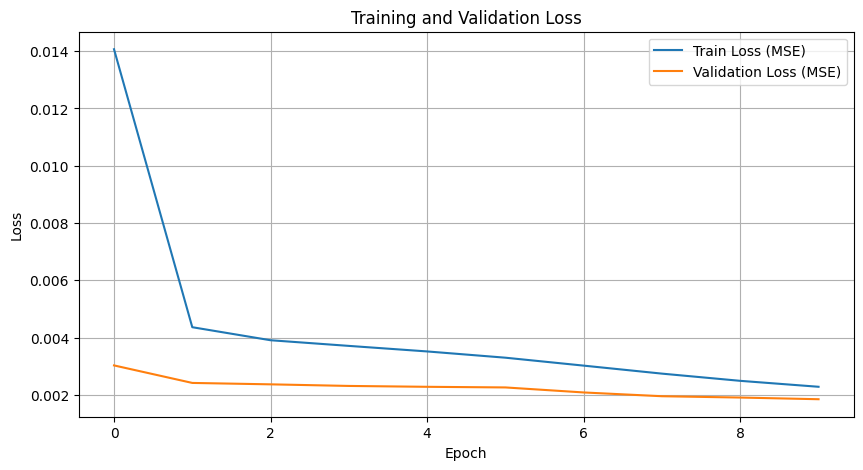

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 7. Model Evaluation

In [13]:
# Predict on the test dataset
predictions = model.predict(X_test)

# Calculate evaluation metrics
mse = np.mean((y_test - predictions.squeeze()) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - predictions.squeeze()))

print(f"Evaluation Metrics on Scaled Test Data:")
print(f"MSE:  {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE:  {mae:.5f}")

296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Evaluation Metrics on Scaled Test Data:
MSE:  0.00219
RMSE: 0.04679
MAE:  0.03404


## 8. Visualize Predictions vs. Actual Volumes

We'll inspect the model's predictions on a sample movement from the test set, unscaling the values back to original traffic volumes.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


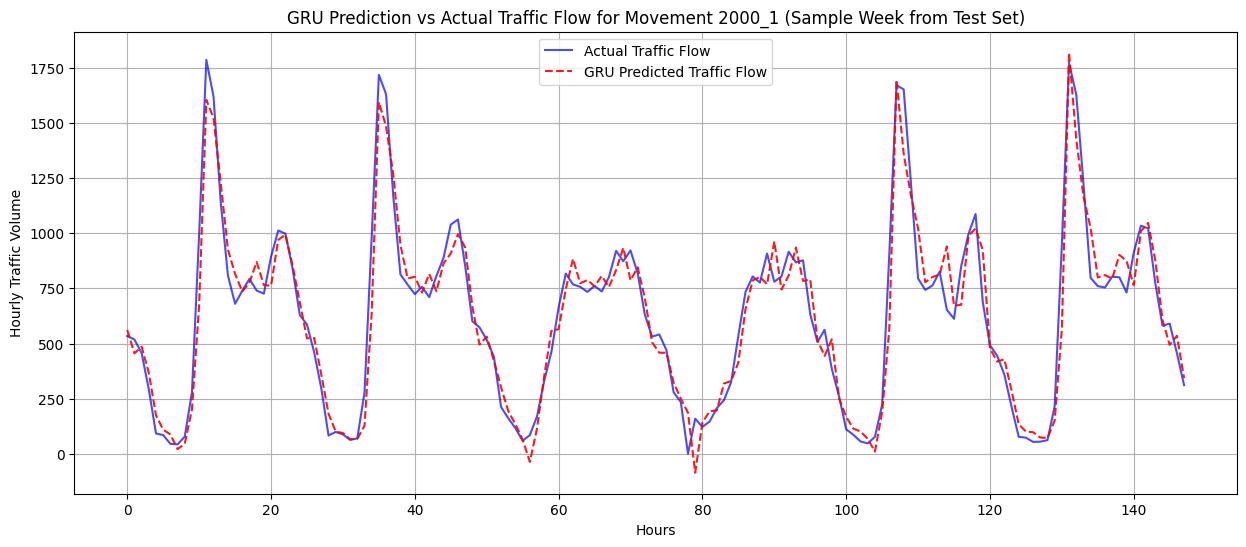

In [14]:
# Let's isolate test data for the same sample movement ('2000_1')
sample_group = df[df['movement_id'] == sample_movement].sort_values('DateTime')
X_sample, y_sample = create_sequences_for_movement(sample_group, seq_length=SEQUENCE_LENGTH)

# Get test portion corresponding to the test_ratio (last 20% of sequences)
split_idx = int(len(X_sample) * 0.8)
X_sample_test = X_sample[split_idx:]
y_sample_test = y_sample[split_idx:]

# Predict
sample_preds = model.predict(X_sample_test)

# Unscale both actuals and predictions
actual_unscaled = scaler.inverse_transform(y_sample_test.reshape(-1, 1)).squeeze()
preds_unscaled = scaler.inverse_transform(sample_preds).squeeze()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(actual_unscaled[:168], label='Actual Traffic Flow', color='blue', alpha=0.7)
plt.plot(preds_unscaled[:168], label='GRU Predicted Traffic Flow', color='red', linestyle='--', alpha=0.9)
plt.title(f"GRU Prediction vs Actual Traffic Flow for Movement {sample_movement} (Sample Week from Test Set)")
plt.xlabel("Hours")
plt.ylabel("Hourly Traffic Volume")
plt.legend()
plt.grid(True)
plt.show()